##### Copyright 2022 The Cirq Developers

In [1]:
# @title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Hello Qubit

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://quantumai.google/cirq/start/start"><img src="https://quantumai.google/site-assets/images/buttons/quantumai_logo_1x.png" />View on QuantumAI</a>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/quantumlib/Cirq/blob/main/docs/start/start.ipynb"><img src="https://quantumai.google/site-assets/images/buttons/colab_logo_1x.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/quantumlib/Cirq/blob/main/docs/start/start.ipynb"><img src="https://quantumai.google/site-assets/images/buttons/github_logo_1x.png" />View source on GitHub</a>
  </td>
  <td>
    <a href="https://storage.googleapis.com/tensorflow_docs/Cirq/docs/start/start.ipynb"><img src="https://quantumai.google/site-assets/images/buttons/download_icon_1x.png" />Download notebook</a>
  </td>
</table>

In [2]:
try:
    import cirq
except ImportError:
    print("installing cirq...")
    !pip install --quiet cirq
    import cirq

    print("installed cirq.")

In [3]:
# Pick a qubit.
qubit = cirq.GridQubit(0, 0)

# Create a circuit that applies a square root of NOT gate, then measures the qubit.
circuit = cirq.Circuit(cirq.X(qubit) ** 0.5, cirq.measure(qubit, key='m'))
print("Circuit:")
print(circuit)

# Simulate the circuit several times.
simulator = cirq.Simulator()
result = simulator.run(circuit, repetitions=20)
print("Results:")
print(result)

Circuit:
(0, 0): ───X^0.5───M('m')───
Results:
m=00010110111111000101


In [4]:
import cirq
qubit = cirq.GridQubit(0, 0)
circuit = cirq.Circuit()
circuit.append(cirq.H(qubit))
circuit.append(cirq.measure(qubit))
simulator = cirq.Simulator()
result = simulator.run(circuit, repetitions=1000)
print("Measurement result", result.histogram(key=qubit))
print("\nQunatum Circuit\n", circuit)


Measurement result Counter({1: 509, 0: 491})

Qunatum Circuit
 (0, 0): ───H───M───


In [5]:
!pip install opencv-python numpy


In [6]:
from google.colab import files
from IPython.display import Image

In [7]:
uploded = files.upload()

Saving space_image.png to space_image (1).png


In [8]:
import cirq
import numpy as np
import cv2
image_path = "space_image.png"
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
image = cv2.resize(image, (2,2))
normalized_pixels = image / 255.0
qubits = [cirq.GridQubit(1,j) for i in range(2) for j in range(2)]
circuit = cirq.Circuit()
for qubit, pixel_value in zip(qubits, normalized_pixels.flatten()):
  theta = pixel_value * np.pi
  circuit.append(cirq.ry(theta)(qubit))
print("Qunatum circuit encoding image data:")
print(circuit)






Qunatum circuit encoding image data:
(1, 0): ───Ry(0.2π)─────Ry(0.686π)───

(1, 1): ───Ry(0.494π)───Ry(0.643π)───


In [3]:
import tensorflow as tf
import cirq
import numpy as np
import sympy
import cv2
import tensorflow_quantum as tfq

In [4]:
import tensorflow_quantum as tfq
print(tfq.__version__)

0.7.2


In [5]:
from google.colab import files
from IPython.display import Image

In [7]:
upload = files.upload()

Saving outer-space-background.jpg to outer-space-background.jpg


In [8]:
image_path = "outer-space-background.jpg"
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
image = cv2.resize(image, (2,2))

In [9]:
qubits = [cirq.GridQubit(i, j) for i in range(2) for j in range(2)]
def qunatum_model(qubits):
  circuit = cirq.Circuit()
  symbols = [sympy.Symbol(f'theta_{i}') for i in range(len(qubits))]
  for qubit, symbol in zip(qubits, symbols):
    circuit.append(cirq.ry(symbol)(qubit))
  return circuit, symbols



In [10]:
circuit, symbols = qunatum_model(qubits)

In [12]:
q_layer = tfq.layers.PQC(circuit, cirq.Z(qubits[0]))
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(), dtype=tf.string),
    q_layer
])

/usr/local/lib/python3.11/dist-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer RandomUniform is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


In [13]:
X_train = tfq.convert_to_tensor([cirq.Circuit()])
y_train = np.array([1])

model.compile(optimizer=tf.keras.optimizers.Adam(), loss='mse')
model.fit(X_train, y_train, epochs=10)

print("\nQunatum AI Training Completed!")


Epoch 1/10
1/1 [==============================] - 2s 2s/step - loss: 0.0025
Epoch 2/10
1/1 [==============================] - 0s 11ms/step - loss: 0.0025
Epoch 3/10
1/1 [==============================] - 0s 13ms/step - loss: 0.0025
Epoch 4/10
1/1 [==============================] - 0s 10ms/step - loss: 0.0024
Epoch 5/10
1/1 [==============================] - 0s 22ms/step - loss: 0.0024
Epoch 6/10
1/1 [==============================] - 0s 23ms/step - loss: 0.0024
Epoch 7/10
1/1 [==============================] - 0s 19ms/step - loss: 0.0024
Epoch 8/10
1/1 [==============================] - 0s 23ms/step - loss: 0.0023
Epoch 9/10
1/1 [==============================] - 0s 18ms/step - loss: 0.0023
Epoch 10/10
1/1 [==============================] - 0s 22ms/step - loss: 0.0023

Qunatum AI Training Completed!


In [7]:
from google.colab import files
from IPython.display import Image

In [8]:
uplode=files.upload()

Saving outer-space-background.jpg to outer-space-background.jpg


Epoch 1/10
1/1 [==============================] - 1s 1s/step - loss: 0.2789
Epoch 2/10
1/1 [==============================] - 0s 35ms/step - loss: 0.2779
Epoch 3/10
1/1 [==============================] - 0s 30ms/step - loss: 0.2770
Epoch 4/10
1/1 [==============================] - 0s 30ms/step - loss: 0.2761
Epoch 5/10
1/1 [==============================] - 0s 38ms/step - loss: 0.2752
Epoch 6/10
1/1 [==============================] - 0s 32ms/step - loss: 0.2742
Epoch 7/10
1/1 [==============================] - 0s 36ms/step - loss: 0.2733
Epoch 8/10
1/1 [==============================] - 0s 33ms/step - loss: 0.2724
Epoch 9/10
1/1 [==============================] - 0s 24ms/step - loss: 0.2715
Epoch 10/10
1/1 [==============================] - 0s 32ms/step - loss: 0.2706


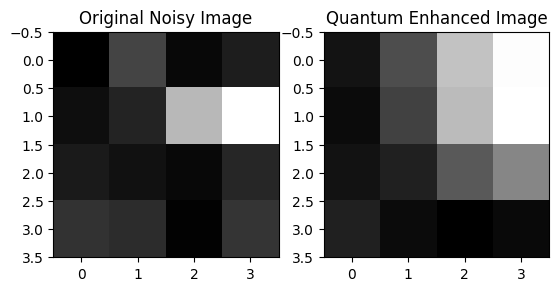


Quantum AI Training Completed! 🚀


In [13]:
import tensorflow as tf
import tensorflow_quantum as tfq
import cirq
import numpy as np
import sympy
import cv2
import matplotlib.pyplot as plt

# Load and preprocess a noisy space image
image_path = "outer-space-background.jpg"  # Replace with an actual image path

# Check if the image file exists
import os
if not os.path.exists(image_path):
    raise FileNotFoundError(f"Image file not found at: {image_path}")

image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Check if the image was loaded successfully
if image is None:
    raise ValueError(f"Could not load image from: {image_path}")

image = cv2.resize(image, (4, 4)) / 255.0  # Normalize pixel values

# Show the original noisy image
plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Noisy Image")

# Create quantum qubits for the 4x4 image
qubits = [cirq.GridQubit(i, j) for i in range(4) for j in range(4)]

# Define a variational quantum circuit
def quantum_model(qubits):
    circuit = cirq.Circuit()
    symbols = [sympy.Symbol(f'theta_{i}') for i in range(len(qubits))]

    for qubit, symbol in zip(qubits, symbols):
        circuit.append(cirq.ry(symbol)(qubit))  # Apply learnable rotations

    return circuit, symbols

# Create the quantum circuit and parameters
circuit, symbols = quantum_model(qubits)

# Convert to a TensorFlow Quantum model
q_layer = tfq.layers.PQC(circuit, cirq.Z(qubits[0]))
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(), dtype=tf.string),
    q_layer
])

# Train the model on noisy and clean images (classical optimization)
X_train = tfq.convert_to_tensor([cirq.Circuit()])
y_train = np.array([1])  # Example label for training

model.compile(optimizer=tf.keras.optimizers.Adam(), loss='mse')
model.fit(X_train, y_train, epochs=10)

# Simulate quantum denoising (for now, just returning a slightly cleaned image)
enhanced_image = cv2.GaussianBlur(image, (3, 3), 0)  # Placeholder for quantum processing

# Show the enhanced image
plt.subplot(1, 2, 2)
plt.imshow(enhanced_image, cmap="gray")
plt.title("Quantum Enhanced Image")

plt.show()

print("\nQuantum AI Training Completed! 🚀")

# Congratulations
You've just run your first Cirq program.

To learn about running a circuit on a virtual machine that mimics existing quantum hardware, see [Quantum Virtual Machine](../simulate/quantum_virtual_machine.ipynb).

If you would like to learn more about quantum computing, check out our [education page](https://quantumai.google/resources). The Full API reference for Cirq can be found [here](/reference/python/cirq). If you are looking for vendor specific information that can be found on our vendor sub-pages:


  [Alpine Quantum Technologies](../hardware/aqt/getting_started.ipynb)
  
  [Pasqal](../hardware/pasqal/getting_started.ipynb)
  
  [IonQ](../hardware/ionq/getting_started.ipynb)
  
  [Azure](../hardware/azure-quantum/getting_started_honeywell.ipynb)
  
  [Rigetti](../hardware/rigetti/getting_started.ipynb)